In [127]:
from embedding.embedding_models import *
from pathlib import Path 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
base_dir = Path("/data/jupyter/event_dynamics/HSMS_LUGOS/output_EL")

files = list(base_dir.rglob("in_event.csv"))

dfs = []
for f in files:
    df = pd.read_csv(f)
    df["event"] = f.parent.name
    dfs.append(df)

global_df = pd.concat(dfs, ignore_index=True)

In [49]:
actor_df = pd.DataFrame()
actor_df['GlobalEventID'] = global_df['GlobalEventID']
actor_df['text_clean'] = global_df['text_clean']
actor_df['event'] = global_df['event']
actor_df['embedding_json'] = global_df['embedding_json']

In [90]:
actor_df["ActorCodes"] = (
    global_df[["Actor1Code", "Actor2Code"]]
    .fillna("")
    .apply(
        lambda row: (
            [row["Actor1Code"][i:i+3] for i in range(0, len(row["Actor1Code"]), 3)] +
            [row["Actor2Code"][i:i+3] for i in range(0, len(row["Actor2Code"]), 3)]
        ),
        axis=1
    )
)


In [129]:
actor_df['ActorCodes']

0             [USA]
1        [USA, MED]
2             [USA]
3             [USA]
4             [USA]
            ...    
30783         [CVL]
30784         [COP]
30785    [RUS, UKR]
30786    [USA, MED]
30787         [USA]
Name: ActorCodes, Length: 30788, dtype: object

In [89]:
rows_with_nan_in_A = global_df[global_df['Actor1CountryCode'].isnull()]
print(rows_with_nan_in_A)

       GlobalEventID        date  Year Actor1Code    Actor1Name  \
6         1018722632  2021-12-05  2021        NaN           NaN   
8         1017746609  2021-12-06  2021        NaN           NaN   
11        1017820145  2021-12-06  2021        chr      CHEROKEE   
13        1019129610  2021-12-07  2021        NaN           NaN   
14        1018027380  2021-12-07  2021        NaN           NaN   
...              ...         ...   ...        ...           ...   
30778     1049400264  2022-06-14  2022        LEG      CONGRESS   
30780     1049248934  2022-06-14  2022        NaN           NaN   
30781     1049240549  2022-06-14  2022        EDU       STUDENT   
30783     1049403382  2022-06-14  2022        CVL     COMMUNITY   
30784     1049367734  2022-06-14  2022        COP  STATE PRISON   

      Actor1CountryCode Actor1EthnicCode Actor2Code      Actor2Name  \
6                   NaN              NaN        COP          DEPUTY   
8                   NaN              NaN        USA  

In [98]:


def make_sampler(df: pd.DataFrame, num: int, col: str = "embedding_json", balanced: bool = True):
    df = df.copy()

    # --- Ensure Actor1Codes is a list per row ---
    # If you might have NaNs, normalize to empty list.
    df["ActorCodes"] = df["ActorCodes"].apply(lambda x: x if isinstance(x, list) else ([] if pd.isna(x) else x))

    # Precompute sets for fast intersection checks
    code_sets = df["ActorCodes"].apply(lambda x: set(x) if isinstance(x, list) else set()).to_numpy()

    # Build inverted index: code -> row indices that contain that code
    code_to_rows = {}
    for idx, s in enumerate(code_sets):
        for c in s:
            code_to_rows.setdefault(c, []).append(idx)
    for c in code_to_rows:
        code_to_rows[c] = np.asarray(code_to_rows[c], dtype=int)

    all_idx = np.arange(len(df), dtype=int)

    def sample_positive_j(i_idx: int, rng: np.random.RandomState) -> int:
        """Pick a j index that shares >=1 Actor1 code with i (allow self if that's all there is)."""
        s = code_sets[i_idx]
        if not s:
            # If i has no codes, can't form a meaningful positive pair; fall back to itself
            return i_idx

        candidates = []
        for c in s:
            candidates.append(code_to_rows.get(c, np.array([], dtype=int)))
        if not candidates:
            return i_idx

        cand = np.unique(np.concatenate(candidates))
        # Prefer not pairing with itself if possible
        if len(cand) > 1:
            cand = cand[cand != i_idx]
            if len(cand) == 0:
                cand = np.unique(np.concatenate(candidates))
        return int(rng.choice(cand))

    def sample_negative_j(i_idx: int, rng: np.random.RandomState, max_tries: int = 50) -> int:
        """Pick a j index with NO Actor1 code overlap with i."""
        s = code_sets[i_idx]
        if not s:
            # If i has no codes, any random row is a valid negative
            return int(rng.choice(all_idx))

        for _ in range(max_tries):
            j_idx = int(rng.choice(all_idx))
            if not (s & code_sets[j_idx]):
                return j_idx

        # Fallback: brute force search (guarantees if there exists any negative)
        # (Could be slow if df is huge, but only hits when sampling is unlucky.)
        for j_idx in all_idx:
            if not (s & code_sets[j_idx]):
                return int(j_idx)

        # Degenerate case: everyone overlaps with everyone (or df too small)
        return i_idx

    # ------------------ sampling ------------------
    rng_i = np.random.RandomState(42)
    rng_pos = np.random.RandomState(0)
    rng_neg = np.random.RandomState(13)

    if not balanced:
        i = df.sample(n=num, random_state=42, replace=True).reset_index(drop=True)
        j = df.sample(n=num, random_state=1, replace=True).reset_index(drop=True)
    else:
        n_pos = num // 2
        n_neg = num - n_pos

        # sample i indices for pos/neg anchors
        i_pos_idx = rng_i.choice(all_idx, size=n_pos, replace=True)
        i_neg_idx = rng_i.choice(all_idx, size=n_neg, replace=True)

        j_pos_idx = np.array([sample_positive_j(ii, rng_pos) for ii in i_pos_idx], dtype=int)
        j_neg_idx = np.array([sample_negative_j(ii, rng_neg) for ii in i_neg_idx], dtype=int)

        i_idx = np.concatenate([i_pos_idx, i_neg_idx])
        j_idx = np.concatenate([j_pos_idx, j_neg_idx])

        i = df.iloc[i_idx].reset_index(drop=True)
        j = df.iloc[j_idx].reset_index(drop=True)

    # ------------------ label y: overlap? ------------------
    y = np.array(
        [int(bool(set(a) & set(b))) for a, b in zip(i["ActorCodes"], j["ActorCodes"])],
        dtype=int
    )

    sampler = pd.DataFrame({
        "GlobalEventID-i": i["GlobalEventID"],
        "GlobalEventID-j": j["GlobalEventID"],
        "features-i": i[col],
        "features-j": j[col],
        "ActorCodes-i": i["ActorCodes"],
        "ActorCodes-j": j["ActorCodes"],
        "y": y
    })

    return sampler


In [99]:

def vectorize(series):
    """
    Takes a pandas Series of embedding_json strings
    and returns a NumPy array of shape (N, 384).
    """
    # Ensure string
    s = series.astype(str).str.strip()

    # Remove brackets, split into float lists
    vecs = (
        s.str[1:-1]                   # strip '[' and ']'
         .str.split(',')              # split by comma
         .apply(lambda x: np.array(x, dtype=np.float32))
         .tolist()
    )

    # Stack into (n_samples, embed_dim)
    return np.vstack(vecs)

In [130]:
sample = make_sampler(actor_df,20000)

In [131]:
print(f"Input training data: {len(global_df)} articles.")
print(f"Training pairs: {len(sample)}")
print(f"  {sample.value_counts('y')}")

Input training data: 30788 articles.
Training pairs: 20000
  y
0    10000
1    10000
Name: count, dtype: int64


In [132]:

i_np = vectorize(sample["features-i"])
j_np = vectorize(sample["features-j"])
i = torch.from_numpy(i_np)
j = torch.from_numpy(j_np)
# Random labels: 0 if dissimilar, 1 if similar.
#make the labels if similar 1, 0 if not
labels = torch.tensor(sample["y"].values, dtype=torch.float32)

logger.info(f"{i.shape}, {j.shape}, {labels.shape}")

2026-02-04 18:00:11,188|INFO|torch.Size([20000, 384]), torch.Size([20000, 384]), torch.Size([20000])


In [136]:
input_dim = 384  # Just like SBERT embeddings
embed_dim = 100  # Chosen embedding dimension
margin = 1.0  # Choose a margin
batch_size=50  # the batch size
n_epochs = 40  # the number of epochs
lr = 0.1  # the learning rate

dataset = ContrastiveDataset(i, j, labels)
model, loss = train_contrastive_loss(dataset, embed_dim, margin=margin,
                                     dist_func=cosine_distance, 
                                     batch_size=batch_size,
                                     epochs=n_epochs,
                                     lr=lr
                                     )
logger.info(f"Model trained!")


2026-02-04 18:00:59,197|DEBUG|Epoch 1/40, Loss: 0.2717
2026-02-04 18:00:59,525|DEBUG|Epoch 2/40, Loss: 0.2425
2026-02-04 18:00:59,824|DEBUG|Epoch 3/40, Loss: 0.2299
2026-02-04 18:01:00,116|DEBUG|Epoch 4/40, Loss: 0.2226
2026-02-04 18:01:00,407|DEBUG|Epoch 5/40, Loss: 0.2175
2026-02-04 18:01:00,700|DEBUG|Epoch 6/40, Loss: 0.2138
2026-02-04 18:01:00,993|DEBUG|Epoch 7/40, Loss: 0.2112
2026-02-04 18:01:01,285|DEBUG|Epoch 8/40, Loss: 0.2087
2026-02-04 18:01:01,578|DEBUG|Epoch 9/40, Loss: 0.2065
2026-02-04 18:01:01,870|DEBUG|Epoch 10/40, Loss: 0.2050
2026-02-04 18:01:02,163|DEBUG|Epoch 11/40, Loss: 0.2033
2026-02-04 18:01:02,454|DEBUG|Epoch 12/40, Loss: 0.2019
2026-02-04 18:01:02,746|DEBUG|Epoch 13/40, Loss: 0.2014
2026-02-04 18:01:03,039|DEBUG|Epoch 14/40, Loss: 0.1998
2026-02-04 18:01:03,333|DEBUG|Epoch 15/40, Loss: 0.1992
2026-02-04 18:01:03,626|DEBUG|Epoch 16/40, Loss: 0.1980
2026-02-04 18:01:03,919|DEBUG|Epoch 17/40, Loss: 0.1973
2026-02-04 18:01:04,213|DEBUG|Epoch 18/40, Loss: 0.1959
2

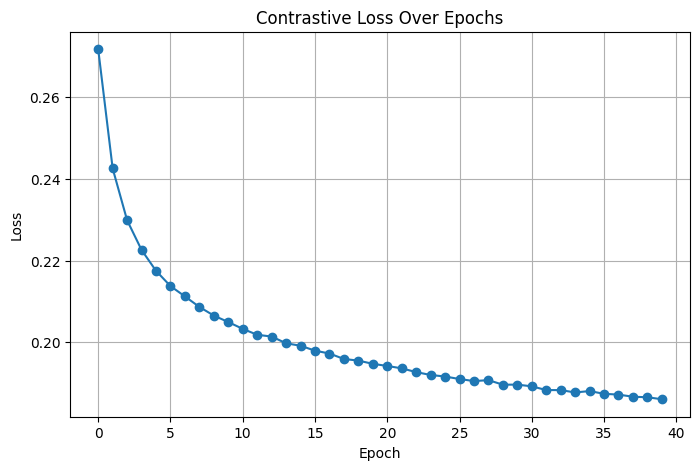

In [137]:
plt.figure(figsize=(8, 5))
plt.plot(loss, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Contrastive Loss Over Epochs")
plt.grid(True)
plt.show()

In [138]:
def avg_pairwise_distance_by_label(x1, x2, labels, metric="cosine"):
    """
    Works with BOTH numpy arrays and torch tensors.
    Computes avg distance for same-label and opposite-label pairs.
    """

    # --- Convert everything to torch tensors if needed ---
    if isinstance(x1, np.ndarray):
        x1 = torch.from_numpy(x1)
    if isinstance(x2, np.ndarray):
        x2 = torch.from_numpy(x2)
    if isinstance(labels, np.ndarray):
        labels = torch.from_numpy(labels)

    x1 = x1.float()
    x2 = x2.float()
    labels = labels.int()

    # --- Distance computation ---
    if metric == "cosine":
        x1n = F.normalize(x1, p=2, dim=1)
        x2n = F.normalize(x2, p=2, dim=1)
        distances = 1 - torch.sum(x1n * x2n, dim=1)

    elif metric == "euclidean":
        distances = torch.norm(x1 - x2, dim=1)

    else:
        raise ValueError("metric must be 'cosine' or 'euclidean'")

    distances = distances.cpu().numpy()
    labels = labels.cpu().numpy()

    same_mask = labels == 1
    opp_mask  = labels == 0

    same_dist = distances[same_mask]
    opp_dist = distances[opp_mask]

    avg_same = distances[same_mask].mean() if same_mask.any() else np.nan
    avg_opp  = distances[opp_mask].mean() if opp_mask.any() else np.nan
    
    return same_dist, opp_dist,{
        "avg_same": float(avg_same),
        "avg_opposite": float(avg_opp),
        "n_same": int(same_mask.sum()),
        "n_opposite": int(opp_mask.sum())
    }

In [139]:
model.eval()

with torch.no_grad():
    i_embed = model(i).cpu().numpy()   # shape: (N, embed_dim)
    j_embed = model(j).cpu().numpy()   # shape: (N, embed_dim)
    
all_embeddings = np.vstack([i_embed, j_embed])

global_ids = np.concatenate([sample["GlobalEventID-i"].values,
                             sample["GlobalEventID-j"].values])

eventcodes = np.concatenate([
    sample["ActorCodes-i"].astype(str),
    sample["ActorCodes-j"].astype(str)
])


all_labels = np.concatenate([labels.numpy(), labels.numpy()])
pair_flag   = np.array([0]*len(i_embed) + [1]*len(j_embed))  # blue = i, orange = j

In [140]:
sbert_same_dist, sbert_opp_dist, stats_sbert_35000 = avg_pairwise_distance_by_label(i, j, labels, metric="cosine")

# Learned embeddings
learned_same_dist, learn_opp_dist, stats_learned_35000 = avg_pairwise_distance_by_label(i_embed, j_embed, labels, metric="cosine")

In [141]:
stats_learned_35000

{'avg_same': 0.44595327973365784,
 'avg_opposite': 0.637930154800415,
 'n_same': 10000,
 'n_opposite': 10000}

In [142]:
stats_sbert_35000

{'avg_same': 0.8387490510940552,
 'avg_opposite': 0.8397409915924072,
 'n_same': 10000,
 'n_opposite': 10000}

In [148]:
data_learned_same = list()
data_learned_opp = list()
learned_values_same = np.array(learned_same_dist, dtype=float) 
data_learned_same.extend([(f, v) for v in learned_values_same]) 
learned_values_opp = np.array(learn_opp_dist, dtype=float) 
data_learned_opp.extend([(f, v) for v in learn_opp_dist])
df_same = pd.DataFrame(data_learned_same, columns=["file", "distance"])
df_same["group"] = "same"

df_opp = pd.DataFrame(data_learned_opp, columns=["file", "distance"])
df_opp["group"] = "opp"

df_learned = pd.concat([df_same, df_opp], ignore_index=True)


In [149]:
df_same = pd.DataFrame(data_learned_same, columns=["file", "distance"])
df_same["group"] = "same"

df_opp = pd.DataFrame(data_learned_opp, columns=["file", "distance"])
df_opp["group"] = "opp"

df_learned = pd.concat([df_same, df_opp], ignore_index=True)



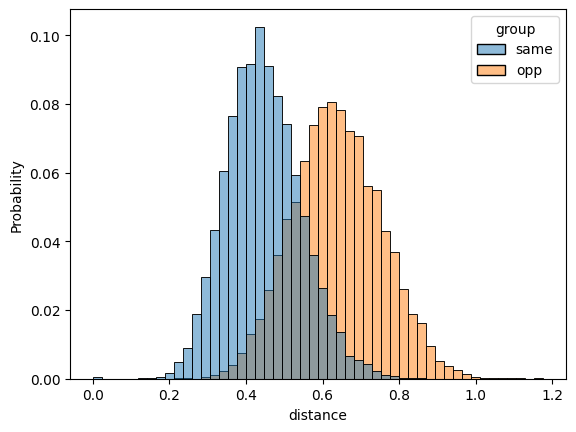

<Figure size 640x480 with 0 Axes>

In [150]:
sns.histplot(
    data=df_learned,
    x="distance",
    hue="group",              # <-- this is the key change
    stat="probability",
    common_norm=False,
    bins=50
)

plt.show()
plt.clf()

